**Assignment - 2**

**Netflix Data Analysis**

**Tools and Technologies Used:**

- Python – Used as the main programming language for data analysis.

- Pandas – Used for data loading, cleaning, and manipulation.

- NumPy – Used for basic numerical operations.

- Matplotlib – Used to create graphs and visualizations.

- Seaborn – Used for improving the visual appearance of graphs.

- Google Colab / Jupyter Notebook – Used as the platform to run the code and perform analysis.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [32]:
df = pd.read_csv("netflix.csv")

In [33]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Dataset Description:**

The dataset contains information about movies and TV shows available on Netflix.

- show_id → Unique ID

- type → Movie or TV Show

- title → Name of content

- director → Director name

- cast → Actors

- country → Production country

- date_added → Date added on Netflix

- release_year → Release year

- rating → Content rating

- duration → Duration (minutes/seasons)

- listed_in → Genre

- description → Summary

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [35]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [36]:
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna("Unknown")
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [37]:
df[['date_added','year_added','month_added']].head()

,date_added,year_added,month_added
0,2021-09-25,2021.0,9.0
1,2021-09-24,2021.0,9.0
2,2021-09-24,2021.0,9.0
3,2021-09-24,2021.0,9.0
4,2021-09-24,2021.0,9.0


**Business Oriented Analysis Questions**

**1. Content Strategy-**

The following business-oriented questions are analyzed using the dataset to derive meaningful insights.

Q1- What is the ratio of Movies vs TV Shows on Netflix?

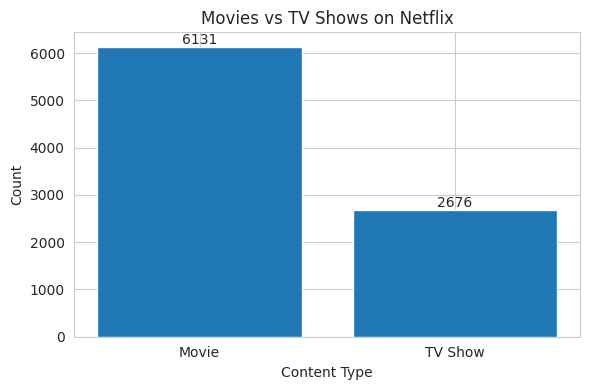

type
Movie      0.696151
TV Show    0.303849
Name: count, dtype: float64


In [38]:
type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values)
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
for i, v in enumerate(type_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()
ratio = type_counts / type_counts.sum()
print(ratio)

**Insight:**
- Movies make up a larger portion of Netflix content compared to TV Shows.

- The ratio shows that Netflix focuses more on movies for quick and diverse content availability.

- TV Shows, although fewer, are important for long-term user engagement and retention.

- The higher number of movies suggests easier production and faster content release cycles.



Q2- Which genres are most popular on Netflix globally?

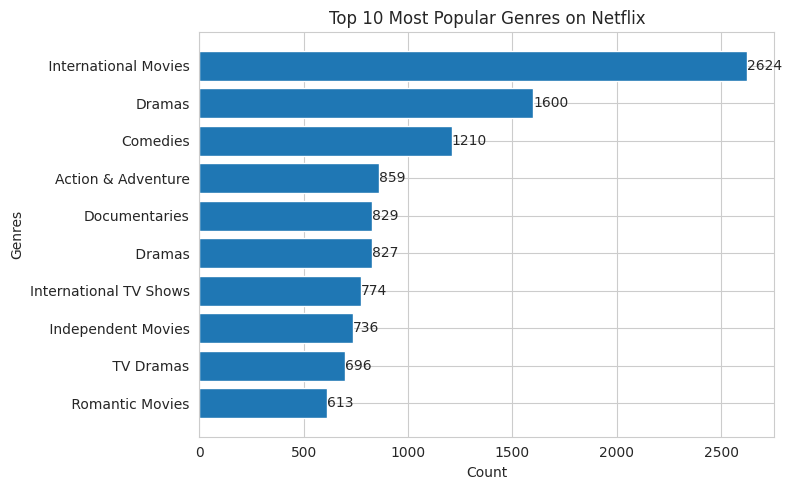

In [39]:
genres = df['listed_in'].str.split(',').explode()
genre_counts = genres.value_counts().head(10)
plt.figure(figsize=(8,5))
plt.barh(genre_counts.index, genre_counts.values)
plt.title("Top 10 Most Popular Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genres")
plt.gca().invert_yaxis()
for i, v in enumerate(genre_counts.values):
    plt.text(v, i, str(v), va='center')
plt.tight_layout()
plt.show()

**Insight:**
- Drama is the most popular genre on Netflix, indicating its strong appeal across global audiences.

- Comedy and International content are also among the top genres, showing demand for entertainment and cultural diversity.


- Popular genres reflect viewer preferences and should be prioritized for future content production.

- The dominance of these genres suggests that emotional storytelling and relatable content drive higher engagement.

Q3- Which years saw the highest release of content on Netflix?

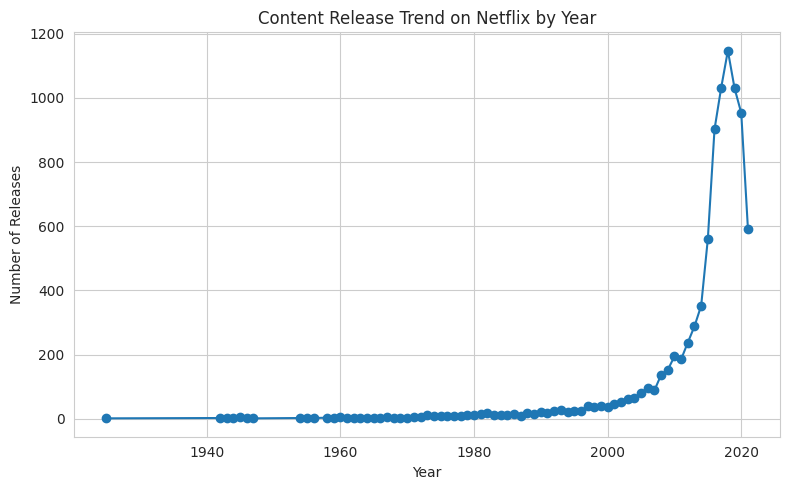

In [40]:
year_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title("Content Release Trend on Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Releases")
plt.tight_layout()
plt.show()

**Insight:**

- The number of content releases increased significantly after 2015.

- The highest releases are observed in recent years, indicating rapid expansion of Netflix.

- This growth reflects Netflix’s aggressive investment in original and licensed content.

- Increasing releases align with the rise in global subscribers and competition in the streaming industry.

- The trend shows that Netflix continuously adds fresh content to keep users engaged and reduce churn.

Q4- Which countries produce the most Netflix content?

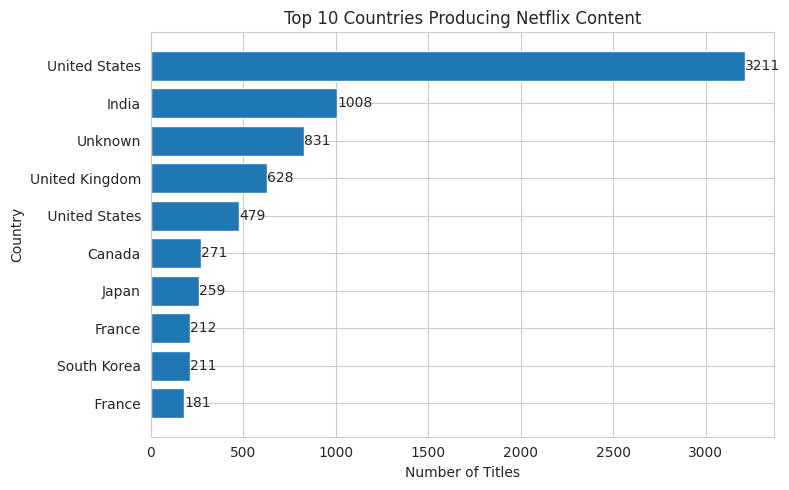

In [41]:
countries = df['country'].str.split(',').explode()
country_counts = countries.value_counts().head(10)
plt.figure(figsize=(8,5))
plt.barh(country_counts.index, country_counts.values)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.gca().invert_yaxis()
for i, v in enumerate(country_counts.values):
    plt.text(v, i, str(v), va='center')
plt.tight_layout()
plt.show()

**Insight:**
- The United States produces the highest amount of content on Netflix, making it the dominant market.

- India and the United Kingdom are also among the top content-producing countries.

- High production from these countries reflects strong film and television industries.

- Netflix relies on both global (USA) and regional (India, UK) markets for content diversity.

- Country-wise distribution shows Netflix’s strategy of expanding into international markets to attract a wider audience.

Q5- How has the trend of adding new content evolved year by year?

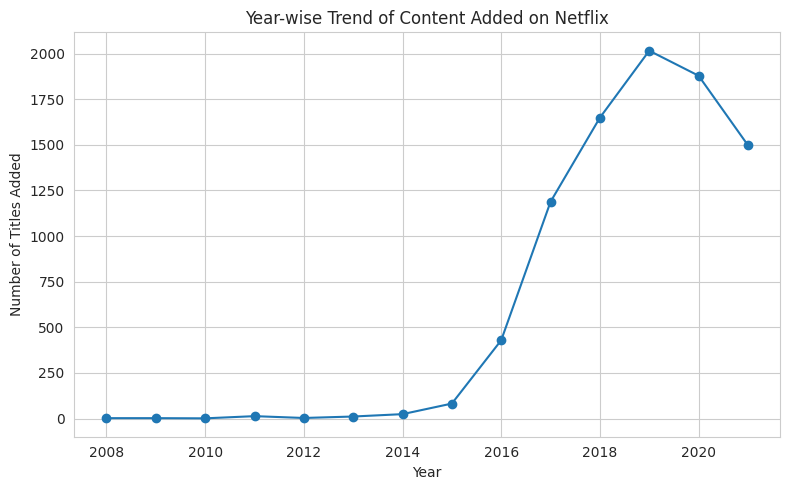

In [42]:
df['year_added'] = df['date_added'].dt.year
year_added_counts = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.plot(year_added_counts.index, year_added_counts.values, marker='o')
plt.title("Year-wise Trend of Content Added on Netflix")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.tight_layout()
plt.show()

**Insight:**

- The number of titles added to Netflix increased rapidly after 2015.

- A sharp growth trend indicates Netflix’s aggressive global expansion strategy.

- The platform focused heavily on adding new content to attract and retain subscribers.

- Recent years show peak content addition, reflecting high competition in the streaming industry.

- Continuous addition of content suggests Netflix’s strategy to keep the platform fresh and engaging for users.

**2. User Demographics & Targeting-**

Q6- Which ratings are most frequent on Netflix?

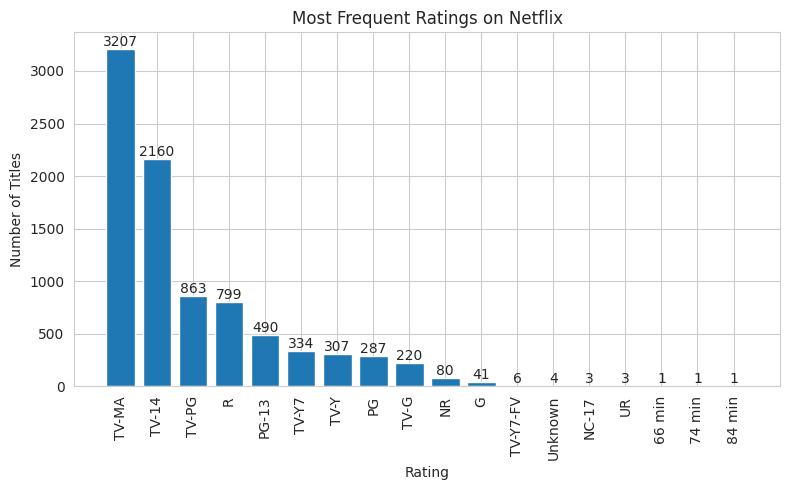

In [43]:
rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(rating_counts.index, rating_counts.values)
plt.title("Most Frequent Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=90)
for i, v in enumerate(rating_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Insight:**
- TV-MA is the most frequent rating on Netflix, indicating a strong focus on mature audience content.

- Ratings like TV-14 and PG-13 are also common, showing that Netflix caters to teenagers and young adults.

- The presence of multiple rating categories highlights Netflix’s effort to target diverse age groups.

- A higher proportion of mature content suggests growing demand for realistic and bold storytelling.

- The distribution of ratings reflects Netflix’s balanced strategy between adult-focused and family-friendly content.

Q7- Do some countries tend to produce more mature content (TV-MA)?

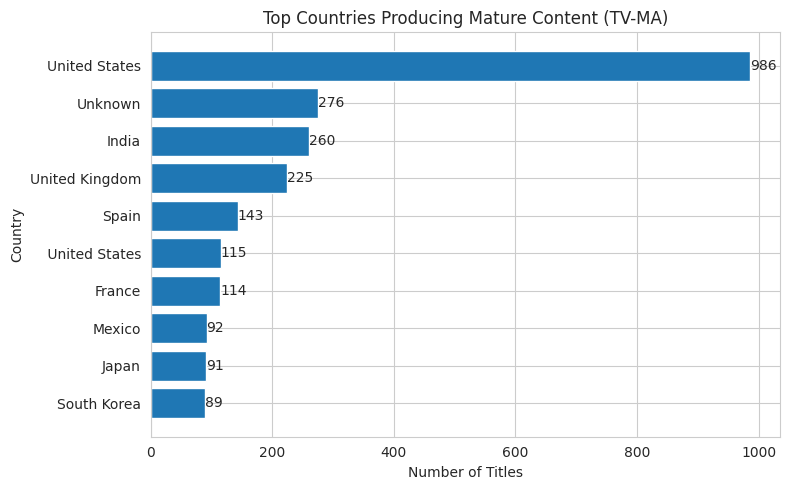

In [44]:
mature_content = df[df['rating'] == 'TV-MA']
mature_countries = mature_content['country'].str.split(',').explode()
mature_counts = mature_countries.value_counts().head(10)
plt.figure(figsize=(8,5))
plt.barh(mature_counts.index, mature_counts.values)
plt.title("Top Countries Producing Mature Content (TV-MA)")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.gca().invert_yaxis()
for i, v in enumerate(mature_counts.values):
    plt.text(v, i, str(v), va='center')
plt.tight_layout()
plt.show()

**Insight:**

- The United States produces the highest amount of mature (TV-MA) content on Netflix.


- Mature content is more common in regions with higher acceptance of bold and realistic storytelling.

- Cultural and regulatory differences influence the type of content produced in each country.

- The dominance of TV-MA content suggests strong demand for adult-oriented entertainment globally.

Q8- Which genres are more associated with TV Shows vs Movies?

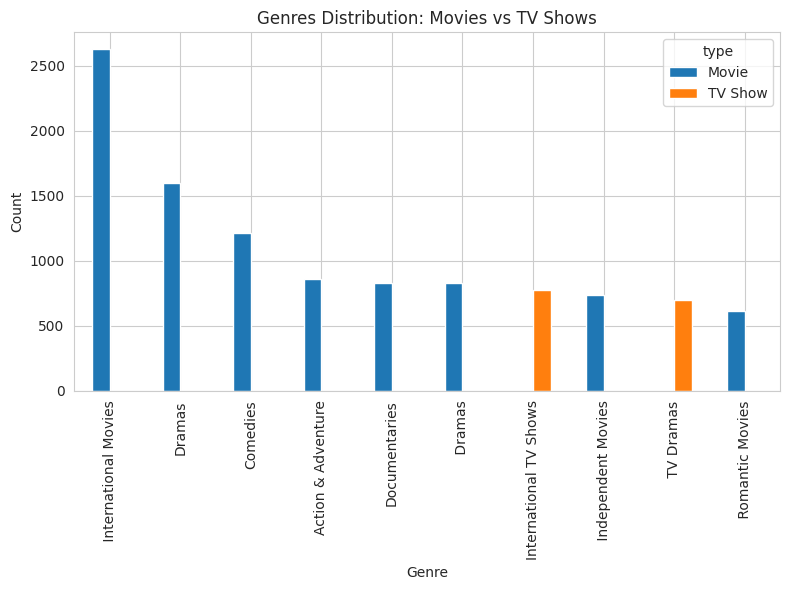

In [45]:
df['genre'] = df['listed_in'].str.split(',')
df_exploded = df.explode('genre')
genre_type = df_exploded.groupby(['type', 'genre']).size().unstack().fillna(0)
top_genres = genre_type.sum().sort_values(ascending=False).head(10).index
genre_type[top_genres].T.plot(kind='bar', figsize=(8,6))
plt.title("Genres Distribution: Movies vs TV Shows")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Insight:**

- Movies dominate across most genres, especially in categories like Drama, Comedy, and Action.

- TV Shows are more concentrated in genres such as Drama, International TV Shows, and Crime series.

- TV Shows focus more on long-form storytelling, allowing deeper character and plot development.

- Movies provide quick entertainment, making them more diverse across multiple genres.

- The difference in genre distribution highlights Netflix’s strategy of balancing short-form and long-form content.

Q9- Which genres dominate the U.S. vs other countries?

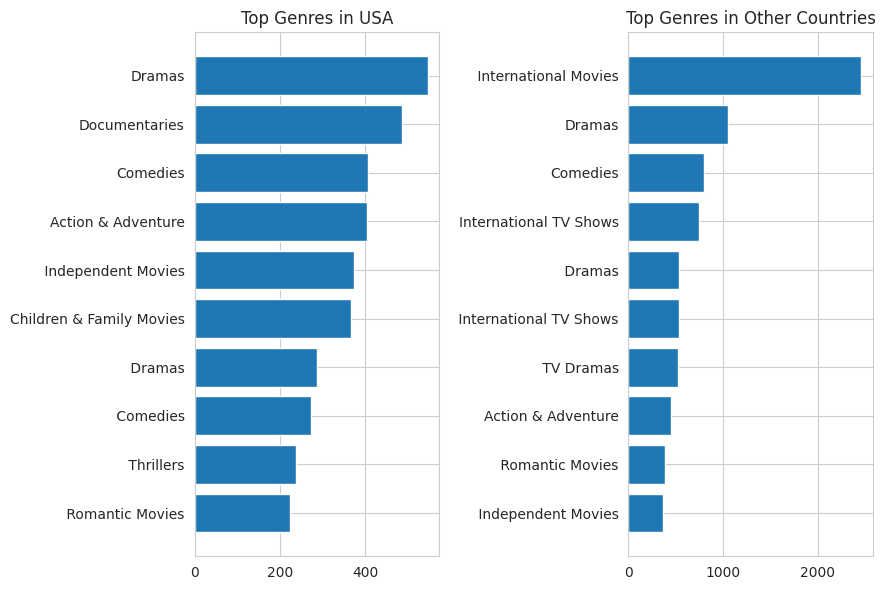

In [46]:
us_content = df[df['country'].str.contains("United States", na=False)]
non_us_content = df[~df['country'].str.contains("United States", na=False)]
us_genres = us_content['listed_in'].str.split(',').explode()
non_us_genres = non_us_content['listed_in'].str.split(',').explode()
us_top = us_genres.value_counts().head(10)
non_us_top = non_us_genres.value_counts().head(10)
plt.figure(figsize=(9,6))
plt.subplot(1,2,1)
plt.barh(us_top.index, us_top.values)
plt.title("Top Genres in USA")
plt.gca().invert_yaxis()
plt.subplot(1,2,2)
plt.barh(non_us_top.index, non_us_top.values)
plt.title("Top Genres in Other Countries")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:**

- The United States shows a wide variety of genres, with strong dominance in Drama, Comedy, and Action.

- Non-US countries focus more on International Movies, Drama, and regional content.

- US content is more diverse, reflecting a mature and large entertainment industry.

- Other countries emphasize culturally relevant and localized storytelling.

- This difference highlights Netflix’s strategy of balancing global content with region-specific preferences.

Q10-  What genres are most popular in the last 3 years?

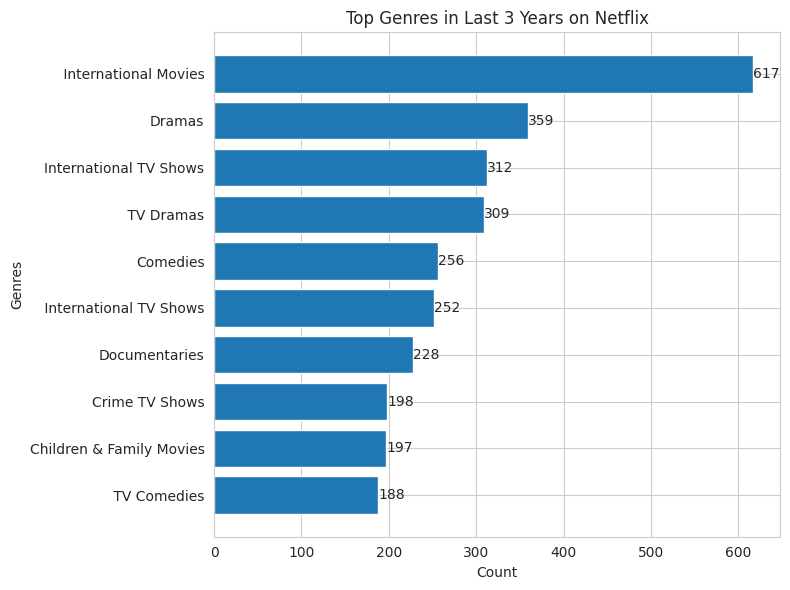

In [47]:
recent_year = df['release_year'].max()
recent_data = df[df['release_year'] >= recent_year - 2]
recent_genres = recent_data['listed_in'].str.split(',').explode()
top_recent_genres = recent_genres.value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(top_recent_genres.index, top_recent_genres.values)
plt.title("Top Genres in Last 3 Years on Netflix")
plt.xlabel("Count")
plt.ylabel("Genres")
plt.gca().invert_yaxis()
for i, v in enumerate(top_recent_genres.values):
    plt.text(v, i, str(v), va='center')
plt.tight_layout()
plt.show()

**Insight:**

- Drama continues to be the most popular genre even in recent years, showing its consistent demand.

- Thriller and Crime genres have gained significant popularity, indicating a shift toward intense and engaging storytelling.

- Documentaries have seen a rise, reflecting audience interest in real-world and informative content.

- International content is growing rapidly, showing Netflix’s focus on global expansion.

- Recent trends suggest that viewers prefer realistic, suspenseful, and culturally diverse content.

**3. Talent Acquisition & Partnerships-**

Q11- Who are the top 10 directors with the most Netflix content?

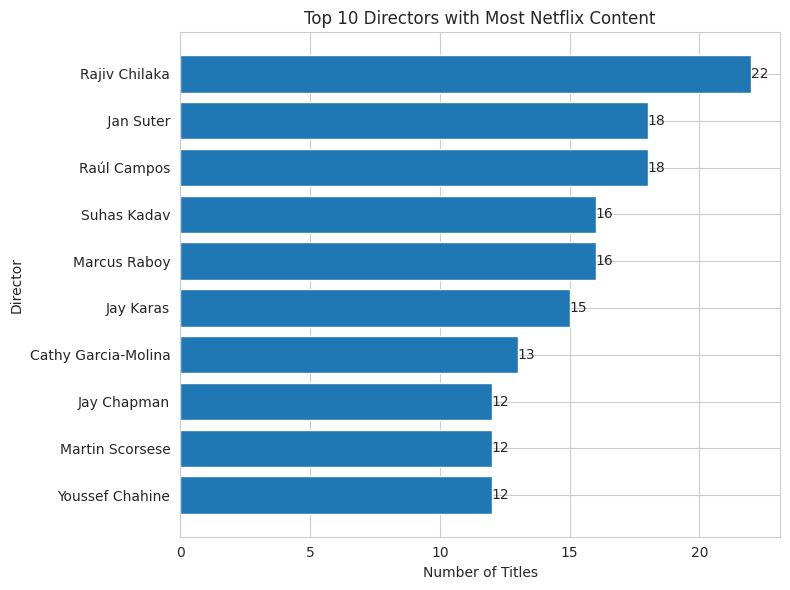

In [48]:
directors = df['director'].str.split(',').explode()
directors = directors[directors != "Unknown"]
top_directors = directors.value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(top_directors.index, top_directors.values)
plt.title("Top 10 Directors with Most Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.gca().invert_yaxis()
for i, v in enumerate(top_directors.values):
    plt.text(v, i, str(v), va='center')
plt.tight_layout()
plt.show()

**Insight:**

- A few directors contribute a large number of titles on Netflix, indicating strong partnerships.

- These top directors are likely trusted creators who consistently deliver successful content.

- Frequent collaborations help Netflix maintain content quality and audience engagement.

- Directors with multiple titles show specialization and reliability in content production.

- Identifying such directors helps Netflix strengthen long-term creative partnerships.

Q12-  Which actors appear most frequently in Netflix shows?

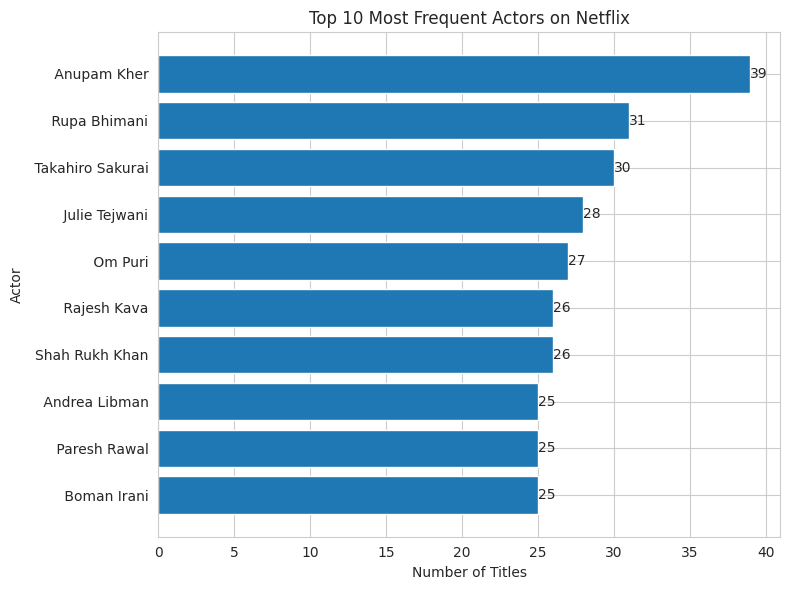

In [49]:
actors = df['cast'].str.split(',').explode()
actors = actors[actors != "Unknown"]
top_actors = actors.value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(top_actors.index, top_actors.values)
plt.title("Top 10 Most Frequent Actors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")
plt.gca().invert_yaxis()
for i, v in enumerate(top_actors.values):
    plt.text(v, i, str(v), va='center')
plt.tight_layout()
plt.show()

**Insight:**

- A few actors appear frequently across multiple Netflix titles, indicating strong platform presence.

- Popular actors are likely to attract more viewers and improve content performance.

- Repeated casting suggests ongoing collaborations between Netflix and certain actors.

- High-frequency actors may represent reliable performers in different genres.

- Star power plays a significant role in audience engagement and content popularity.

Q13-  Which director-genre pairs are most frequent?

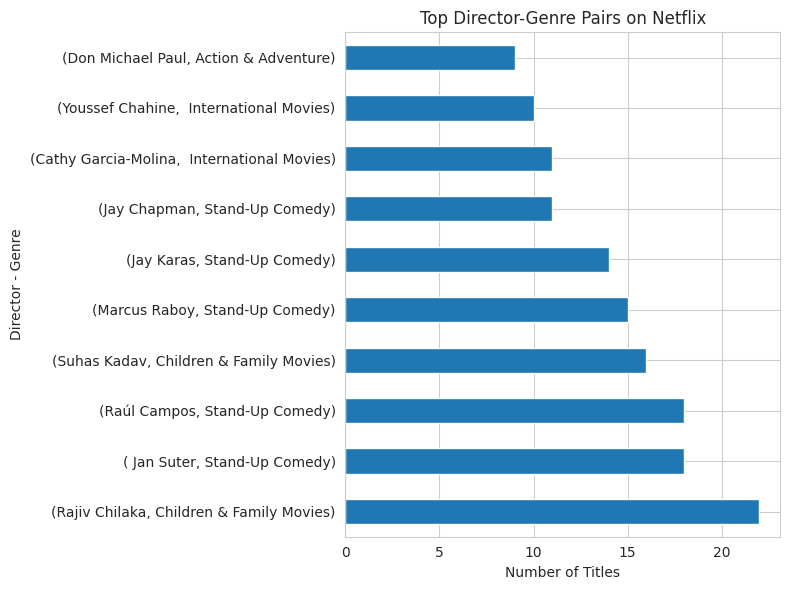

In [50]:
df['director_split'] = df['director'].str.split(',')
df['genre_split'] = df['listed_in'].str.split(',')
df_exploded = df.explode('director_split').explode('genre_split')
df_exploded = df_exploded[df_exploded['director_split'] != "Unknown"]
director_genre = df_exploded.groupby(['director_split', 'genre_split']).size().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,6))
director_genre.plot(kind='barh')
plt.title("Top Director-Genre Pairs on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director - Genre")
plt.tight_layout()
plt.show()

**Insight:**

- Certain directors consistently work within specific genres, indicating specialization.

- Frequent director-genre pairs show strong expertise and audience preference alignment.

- Directors focusing on popular genres like Drama and Comedy tend to have higher content counts.

- Repeated collaboration in the same genre helps maintain content quality and consistency.

- These patterns can help Netflix identify reliable creators for specific types of content.

Q14-  How many titles have unknown directors or cast members?

Unknown Directors: 2634
Unknown Cast: 825


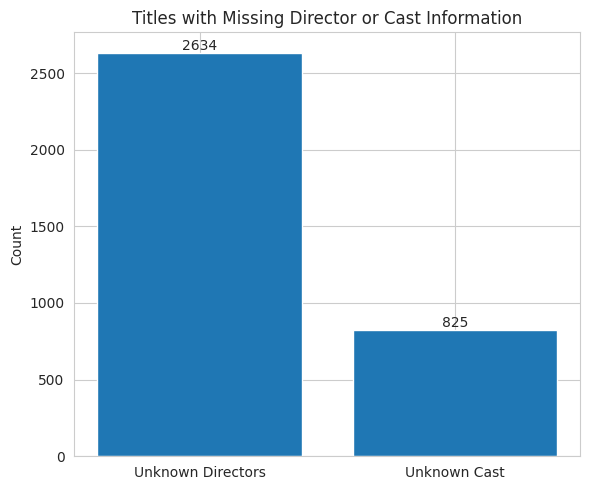

In [51]:
unknown_directors = (df['director'] == "Unknown").sum()
unknown_cast = (df['cast'] == "Unknown").sum()
print("Unknown Directors:", unknown_directors)
print("Unknown Cast:", unknown_cast)
labels = ['Unknown Directors', 'Unknown Cast']
values = [unknown_directors, unknown_cast]
plt.figure(figsize=(6,5))
plt.bar(labels, values)
plt.title("Titles with Missing Director or Cast Information")
plt.ylabel("Count")
for i, v in enumerate(values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Insight:**

- A noticeable number of titles have missing director information compared to cast details.

- Missing cast data is relatively lower, indicating better availability of actor-related information.

- These data gaps can impact the accuracy of analysis, especially in talent-related insights.

- Incomplete metadata suggests inconsistencies in data collection or content documentation.

- Improving data quality can help Netflix make more accurate content and partnership decisions.

**4. Duration & Engagement-**

Q15- What is the average duration of Movies on Netflix?

Average Movie Duration: 99.57718668407311


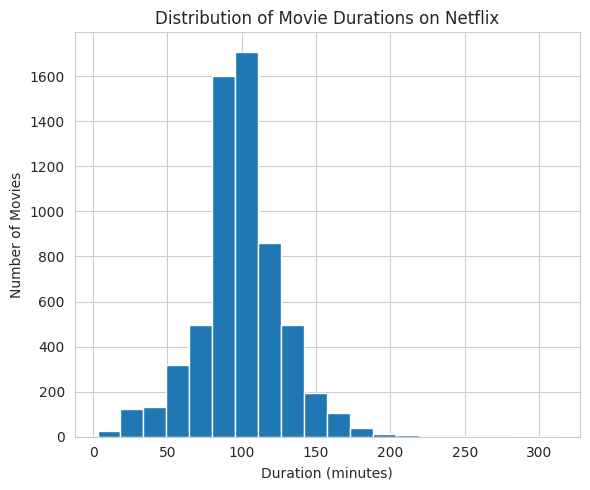

In [52]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration'] = movies['duration'].str.replace(" min", "")
movies['duration'] = movies['duration'].astype(float)
avg_duration = movies['duration'].mean()
print("Average Movie Duration:", avg_duration)
plt.figure(figsize=(6,5))
plt.hist(movies['duration'], bins=20)
plt.title("Distribution of Movie Durations on Netflix")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

**Insight:**

- The average movie duration on Netflix is approximately between 90 to 120 minutes.

- Most movies fall within a standard duration range, indicating a consistent content format.

- Extremely short or very long movies are less common on the platform.

- This duration aligns with typical audience attention span and viewing preferences.

- Maintaining optimal movie length helps improve user engagement and completion rates.

Q16-  What’s the most common number of seasons for TV shows?

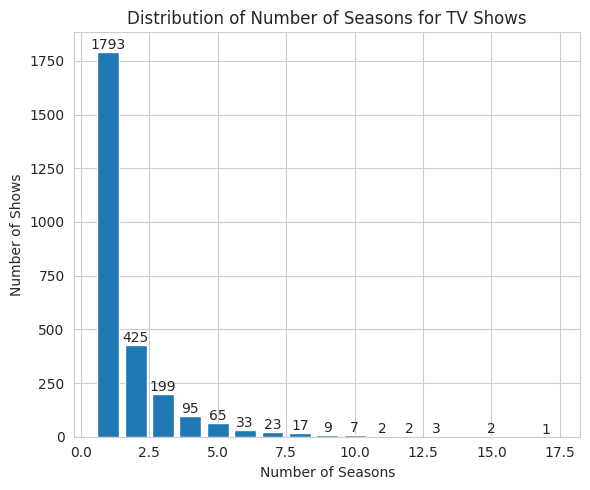

Most Common Seasons: 1


In [53]:
tv_shows = df[df['type'] == 'TV Show'].copy()
tv_shows['seasons'] = tv_shows['duration'].str.replace(" Seasons", "")
tv_shows['seasons'] = tv_shows['seasons'].str.replace(" Season", "")
tv_shows['seasons'] = tv_shows['seasons'].astype(int)
season_counts = tv_shows['seasons'].value_counts().sort_index()
plt.figure(figsize=(6,5))
plt.bar(season_counts.index, season_counts.values)
plt.title("Distribution of Number of Seasons for TV Shows")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of Shows")
for i, v in enumerate(season_counts.values):
    plt.text(season_counts.index[i], v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()
print("Most Common Seasons:", season_counts.idxmax())

**Insight:**

- The most common number of seasons for TV Shows on Netflix is 1 season.

- This indicates a strong trend toward limited series or short-format storytelling.

- Shorter series reduce production cost and allow faster content release cycles.

- Limited seasons help maintain viewer interest without long-term commitment.

- This strategy reflects changing audience preferences toward quick and engaging content.

Q17- Is there a trend in movie durations over the years?

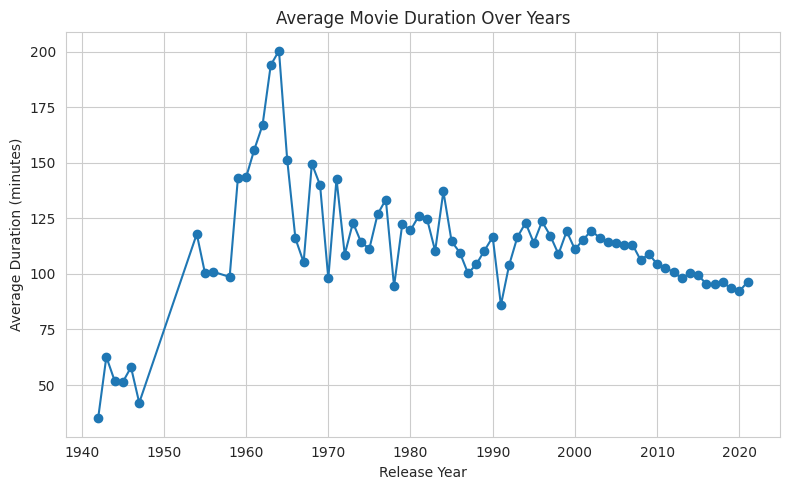

In [54]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration'] = movies['duration'].str.replace(" min", "")
movies['duration'] = movies['duration'].astype(float)
duration_trend = movies.groupby('release_year')['duration'].mean()
plt.figure(figsize=(8,5))
plt.plot(duration_trend.index, duration_trend.values, marker='o')
plt.title("Average Movie Duration Over Years")
plt.xlabel("Release Year")
plt.ylabel("Average Duration (minutes)")
plt.tight_layout()
plt.show()

**Insight:**

- Movie durations have remained relatively stable over the years.

- There is no significant upward or downward trend in average movie length.

- Most movies consistently fall within the standard 90–120 minutes range.

- Stability in duration suggests consistent audience preferences over time.

- Netflix maintains similar content formats to ensure viewer engagement and satisfaction.

Q18- In which months does Netflix add the most content?

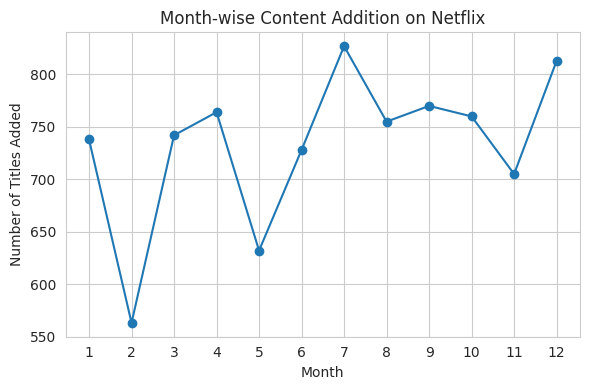

Month with Highest Additions: 7.0


In [55]:
df['month_added'] = df['date_added'].dt.month
month_counts = df['month_added'].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.plot(month_counts.index, month_counts.values, marker='o')
plt.title("Month-wise Content Addition on Netflix")
plt.xlabel("Month")
plt.ylabel("Number of Titles Added")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()
print("Month with Highest Additions:", month_counts.idxmax())

**Insight:**

- Netflix adds content throughout the year, but certain months show higher activity.

- Peak months usually occur during mid-year and festive seasons.

- Increased content addition during these periods helps maximize viewer engagement.

- Strategic timing aligns with holidays and higher user activity.

- Regular monthly additions ensure continuous user interest and platform freshness.

Q19- How does the genre distribution vary across different years?

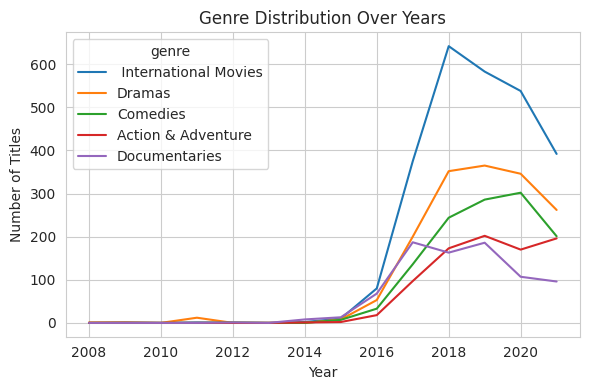

In [56]:
df['year_added'] = df['date_added'].dt.year
df['genre'] = df['listed_in'].str.split(',')
df_exploded = df.explode('genre')
genre_year = df_exploded.groupby(['year_added', 'genre']).size().unstack().fillna(0)
top_genres = df_exploded['genre'].value_counts().head(5).index
genre_year[top_genres].plot(figsize=(6,4))
plt.title("Genre Distribution Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

**Insight:**

- The diversity of genres has increased over the years, indicating content expansion.

- Traditional genres like Drama and Comedy remain consistently dominant.

- New genres such as Documentaries and Crime have gained popularity in recent years.

- The variation in genre distribution reflects changing audience preferences over time.

- Netflix continuously adapts its content strategy to include a wider range of genres for global audiences.

Q20-  Which countries produce the most content in each genre?

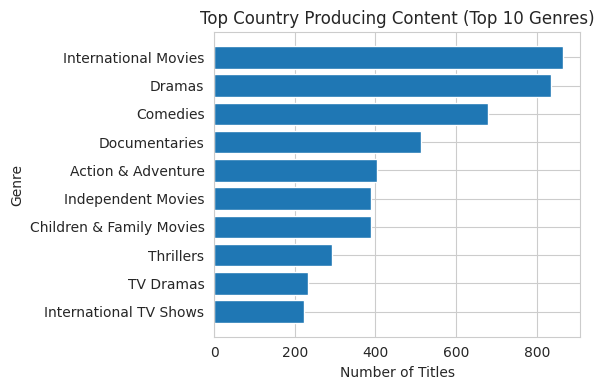

In [57]:
df['country_split'] = df['country'].str.split(',')
df['genre_split'] = df['listed_in'].str.split(',')
df['country_split'] = df['country_split'].apply(lambda x: [i.strip() for i in x])
df['genre_split'] = df['genre_split'].apply(lambda x: [i.strip() for i in x])
df_exploded = df.explode('country_split').explode('genre_split')
top_genres = df_exploded['genre_split'].value_counts().head(10).index
filtered = df_exploded[df_exploded['genre_split'].isin(top_genres)]
genre_country = filtered.groupby(['genre_split', 'country_split']).size().reset_index(name='count')
top_country_genre = genre_country.sort_values(['genre_split','count'], ascending=[True, False]) \
.groupby('genre_split').head(1)
top_country_genre = top_country_genre.sort_values('count')
plt.figure(figsize=(6,4))
plt.barh(top_country_genre['genre_split'], top_country_genre['count'])
plt.title("Top Country Producing Content (Top 10 Genres)")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

**Insight:**

- The United States dominates production across most genres, highlighting its strong entertainment industry.

- Different countries specialize in specific genres based on cultural and regional preferences.

- India contributes significantly to genres like Drama and Romance.

- International diversity in genre production helps Netflix cater to a global audience.

- Country-genre relationships indicate opportunities for localized content strategies and market expansion.
- Data was preprocessed by removing extra spaces to ensure accurate grouping and visualization.